In [ ]:
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("results/results_qwen_fixed_2026-05-29.csv")


def _short_model_name(name: str) -> str:
    n = str(name).split("/")[-1]
    n = n.replace("-Instruct", "").replace("-Base", "")
    return n


def _family(name: str) -> str:
    n = str(name).lower()
    if "qwen" in n:    return "Qwen"
    if "llama" in n:   return "Llama"
    if "gemma" in n:   return "Gemma"
    if "mistral" in n or "ministral" in n: return "Mistral"
    if "granite" in n: return "Granite"
    if "hunyuan" in n: return "Hunyuan"
    return "Other"


def _size_b(name: str) -> float:
    """Parameter count in billions parsed from the model name. NaN if not found."""
    s = str(name)
    # Match floats followed by B/b boundary; take the last (rightmost) hit.
    matches = re.findall(r"([\d.]+)\s*[Bb]\b", s)
    if matches:
        try:
            return float(matches[-1])
        except ValueError:
            pass
    # Fallback for tokens like "-3b-" inside lowercased ids.
    m = re.search(r"[-_]([\d.]+)b[-_]", s.lower())
    return float(m.group(1)) if m else float("nan")


df["guesser_label"] = df["guesser_model"].str.split("/").str[-1]
df["secret_label"]  = df["secret_model"].str.split("/").str[-1]
df["guesser_short"] = df["guesser_model"].apply(_short_model_name)
df["secret_short"]  = df["secret_model"].apply(_short_model_name)
df["family"]        = df["guesser_model"].apply(_family)
df["size_b"]        = df["guesser_model"].apply(_size_b)
df["config"] = df["mode"] + "\n" + df["guesser_label"] + " / " + df["secret_label"]


# Preferred metric: strict verified wins (fallback for older CSV schema)
if "num_verified_wins" in df.columns:
    df["avg_verified_win_score"] = df["num_verified_wins"] / df["num_games"]

print(f"{len(df)} run(s) loaded")
df


45 run(s) loaded


,run_id,seed,mode,guesser_model,secret_model,num_games,num_wins,num_verified_wins,num_high_confidence,num_leaked,...,co2_g,co2_per_game_g,guesser_label,secret_label,guesser_short,secret_short,family,size_b,config,avg_verified_win_score
0,slurm-batch9488-seed1-9497,1,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-1.8B-Instruct,100,38,5,5,0,...,133.702153,1.337022,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,Hunyuan-1.8B,Hunyuan-1.8B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-1.8B-Ins...,0.05
1,slurm-batch9488-seed2-9498,2,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-1.8B-Instruct,100,39,4,4,0,...,127.908894,1.279089,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,Hunyuan-1.8B,Hunyuan-1.8B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-1.8B-Ins...,0.04
2,slurm-batch9488-seed3-9499,3,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-1.8B-Instruct,100,28,1,1,0,...,130.814092,1.308141,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,Hunyuan-1.8B,Hunyuan-1.8B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-1.8B-Ins...,0.01
3,slurm-batch9488-seed4-9500,4,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-1.8B-Instruct,100,36,3,2,0,...,122.758699,1.227587,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,Hunyuan-1.8B,Hunyuan-1.8B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-1.8B-Ins...,0.03
4,slurm-batch9488-seed5-9501,5,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-1.8B-Instruct,100,32,2,2,0,...,117.012628,1.170126,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,Hunyuan-1.8B,Hunyuan-1.8B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-1.8B-Ins...,0.02
5,slurm-batch9489-seed1-9632,1,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-4B-Instruct,100,27,2,2,0,...,174.545502,1.745455,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,Hunyuan-1.8B,Hunyuan-4B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-4B-Instruct,0.02
6,slurm-batch9489-seed2-9633,2,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-4B-Instruct,100,27,7,5,0,...,132.992748,1.329927,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,Hunyuan-1.8B,Hunyuan-4B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-4B-Instruct,0.07
7,slurm-batch9489-seed3-9634,3,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-4B-Instruct,100,24,3,3,0,...,133.025668,1.330257,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,Hunyuan-1.8B,Hunyuan-4B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-4B-Instruct,0.03
8,slurm-batch9489-seed4-9635,4,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-4B-Instruct,100,27,3,3,0,...,156.475241,1.564752,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,Hunyuan-1.8B,Hunyuan-4B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-4B-Instruct,0.03
9,slurm-batch9489-seed5-9636,5,tool,tencent/Hunyuan-1.8B-Instruct,tencent/Hunyuan-4B-Instruct,100,19,4,4,0,...,161.546447,1.615464,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,Hunyuan-1.8B,Hunyuan-4B,Hunyuan,1.8,tool\nHunyuan-1.8B-Instruct / Hunyuan-4B-Instruct,0.04


In [2]:
df[df["guesser_short"]=="Hunyuan-4B"].groupby("secret_short")["avg_verified_win_score"].mean()

secret_short
Hunyuan-1.8B    0.002
Hunyuan-4B      0.004
Hunyuan-7B      0.030
Name: avg_verified_win_score, dtype: float64

In [43]:
df[(df["guesser_short"] == "Hunyuan-1.8B") & (df["secret_short"] == "Hunyuan-7B")]["verified_layer1_agreement"].mean()

np.float64(0.882)

In [44]:
df[df["family"] == "Hunyuan"].groupby(["guesser_short","secret_short"])["avg_best_guess_sim"].mean().round(3)

guesser_short  secret_short
Hunyuan-1.8B   Hunyuan-1.8B    0.148
               Hunyuan-4B      0.160
               Hunyuan-7B      0.143
Hunyuan-4B     Hunyuan-1.8B    0.195
               Hunyuan-4B      0.080
               Hunyuan-7B      0.093
Hunyuan-7B     Hunyuan-1.8B    0.088
               Hunyuan-4B      0.114
               Hunyuan-7B      0.144
Name: avg_best_guess_sim, dtype: float64

## 0 — Fix CO₂ with a single carbon intensity

CarbonTracker's geolocation toggled between DK (143.30 g/kWh) and the global fallback (445.00 g/kWh) per round, so raw `co2_g` is not comparable across runs. Energy (`energy_kwh`) is physically measured per second via NVML/RAPL and is the trustworthy number: we recompute CO₂ from it using one fixed intensity.

**Source used:** Electricity Maps, zone **DK-DK2** (East Denmark), **April 2026** monthly average = **104 gCO₂eq/kWh** (96% carbon-free, 88% renewable). <https://app.electricitymaps.com/zone/DK-DK2>

In [4]:
# Override CarbonTracker's noisy CO2 with a fixed grid intensity.
# Source: Electricity Maps, East Denmark (DK-DK2), April 2026 monthly average.
# https://app.electricitymaps.com/zone/DK-DK2
# (96% carbon-free, 88% renewable that month.)
CO2_INTENSITY_G_PER_KWH = 104.0

df["energy_kwh"]        = pd.to_numeric(df["energy_kwh"], errors="coerce")
df["energy_per_game_wh"] = pd.to_numeric(df["energy_per_game_wh"], errors="coerce")

df["co2_g"]          = df["energy_kwh"] * CO2_INTENSITY_G_PER_KWH
df["co2_per_game_g"] = df["energy_per_game_wh"] / 1000.0 * CO2_INTENSITY_G_PER_KWH

print(f"Recomputed CO2 using fixed intensity = {CO2_INTENSITY_G_PER_KWH} g/kWh (DK-DK2, Apr 2026)")
df[["guesser_label", "secret_label", "energy_per_game_wh", "co2_per_game_g"]]

Recomputed CO2 using fixed intensity = 104.0 g/kWh (DK-DK2, Apr 2026)


,guesser_label,secret_label,energy_per_game_wh,co2_per_game_g
0,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,3.004543,0.312472
1,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,2.874357,0.298933
2,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,2.939643,0.305723
3,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,2.785051,0.289645
4,Hunyuan-1.8B-Instruct,Hunyuan-1.8B-Instruct,2.629497,0.273468
5,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,3.922371,0.407927
6,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,2.988601,0.310815
7,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,2.989341,0.310891
8,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,3.546843,0.368872
9,Hunyuan-1.8B-Instruct,Hunyuan-4B-Instruct,3.630257,0.377547


## 1 — Win rate by mode & model
Shows how often the guesser wins across different configurations. When multiple seeds exist, bars show the mean and error bars show standard deviation.

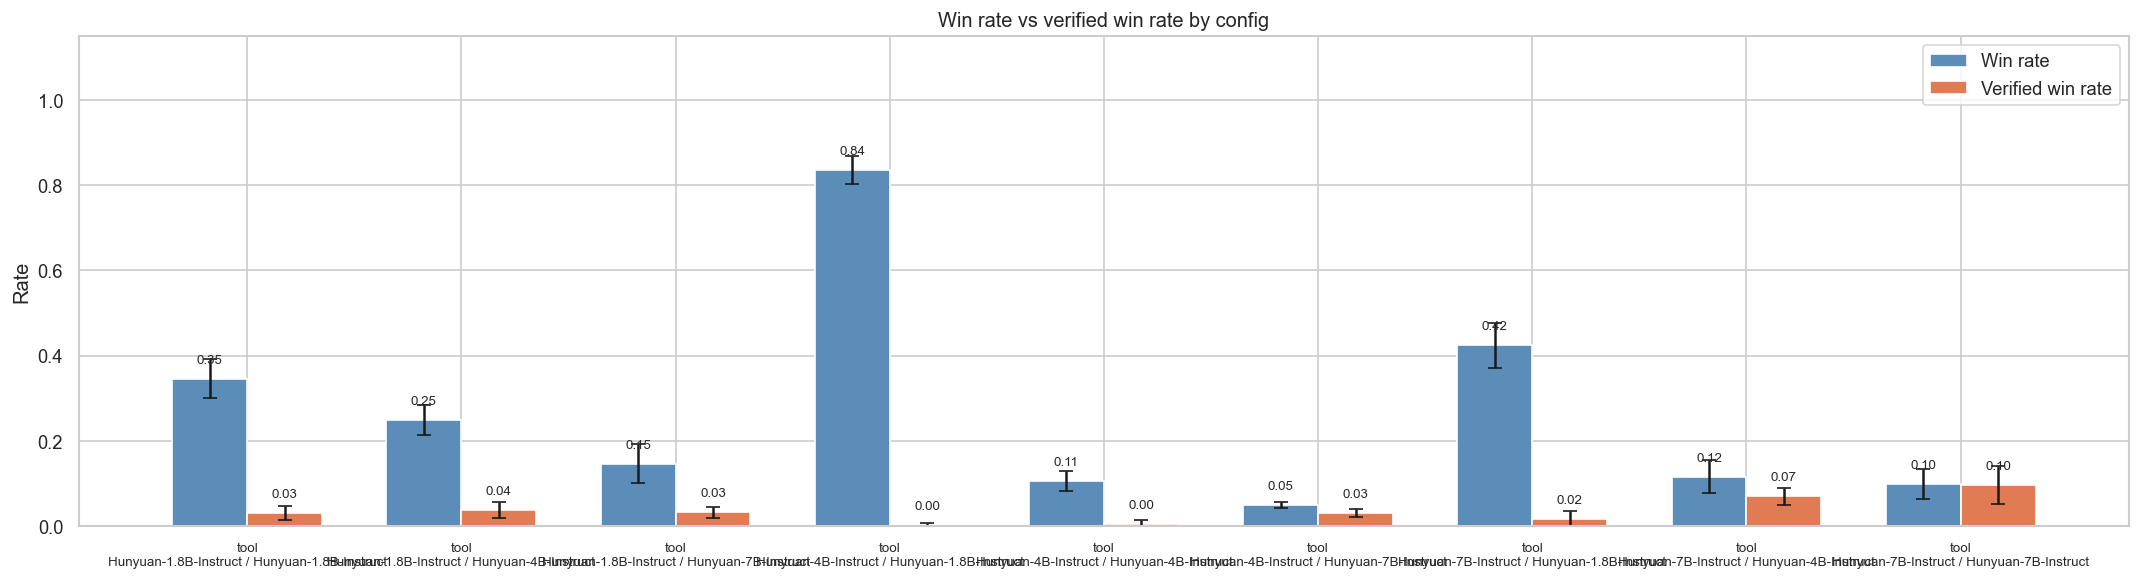

In [5]:
grouped = df.groupby("config")[["avg_win_score", "avg_verified_win_score"]].agg(["mean", "std"]).reset_index()
grouped.columns = ["config", "win_mean", "win_std", "verified_mean", "verified_std"]
grouped[["win_std", "verified_std"]] = grouped[["win_std", "verified_std"]].fillna(0)

x = np.arange(len(grouped))
width = 0.35
fig, ax = plt.subplots(figsize=(max(9, len(grouped) * 2.0), 5))

bars1 = ax.bar(x - width/2, grouped["win_mean"], width, yerr=grouped["win_std"],
               capsize=4, label="Win rate", color="#5b8db8", edgecolor="white")
bars2 = ax.bar(x + width/2, grouped["verified_mean"], width, yerr=grouped["verified_std"],
               capsize=4, label="Verified win rate", color="#e07b54", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(grouped["config"], fontsize=8)
for lbl in ax.get_xticklabels():
    lbl.set_rotation(0)
    lbl.set_ha("center")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1.15)
ax.set_title("Win rate vs verified win rate by config")
ax.legend()

for bar, val in zip(bars1, grouped["win_mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars2, grouped["verified_mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f"{val:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 1b — Secret keeper reliability
How well did the secret keeper model behave? `avg_secret_keeper_accuracy` measures how often it gave consistent answers. Leaked games are ones where the secret keeper revealed the answer in a YES/NO response. False correct games are ones where it said CORRECT but the guess didn't match the secret.

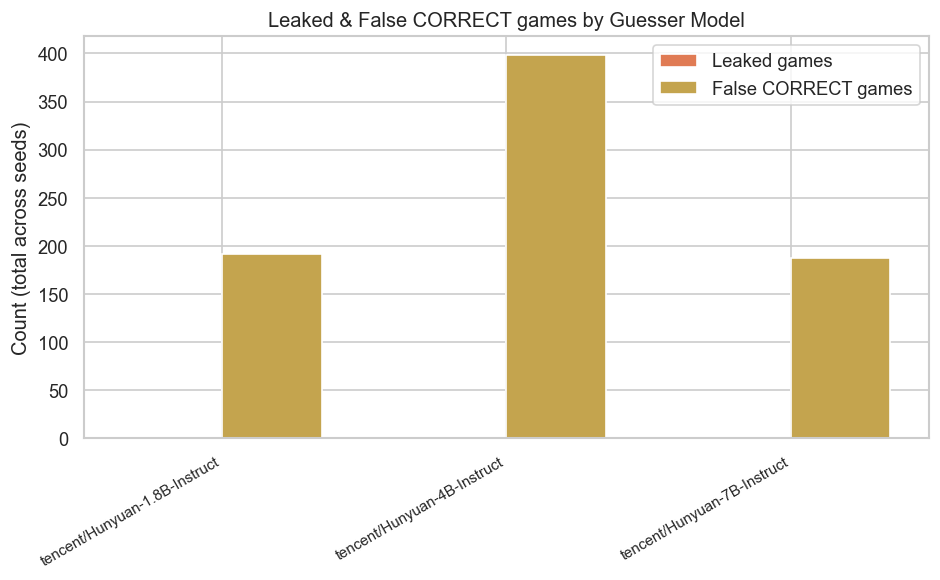

In [6]:
new_cols = {"num_leaked", "num_false_correct"}
if not new_cols.issubset(df.columns):
    print("Columns not found — re-run gather_results.py with new data.")
else:                                       
    sk = df.groupby("guesser_model").agg(
        leaked=("num_leaked", "sum"),
        false_correct=("num_false_correct", "sum"),                                                           
    ).reset_index()                     
    sk["guesser_model"] = sk["guesser_model"].str.replace("Qwen/", "", regex=False)                           
    sk = sk.sort_values("leaked", ascending=False)                                                            
                                            
    x = np.arange(len(sk))                                                                                    
    width = 0.35                                                                                              
                                                                                                            
    fig, ax = plt.subplots(figsize=(8, 5))                                                                    
    ax.bar(x - width/2, sk["leaked"],        width, label="Leaked games",        color="#e07b54",             
edgecolor="white")                          
    ax.bar(x + width/2, sk["false_correct"], width, label="False CORRECT games", color="#c4a44e",             
edgecolor="white")                          
    ax.set_xticks(x)                                                                                          
    ax.set_xticklabels(sk["guesser_model"], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Count (total across seeds)")                                                               
    ax.set_title("Leaked & False CORRECT games by Guesser Model")
    ax.legend()                                                                                               
    plt.tight_layout()                                                                                        
    plt.show()

## 2 — Score breakdown per config
Compares all evaluation metrics side by side. Good for spotting whether a model is strong at one layer but weak at another.

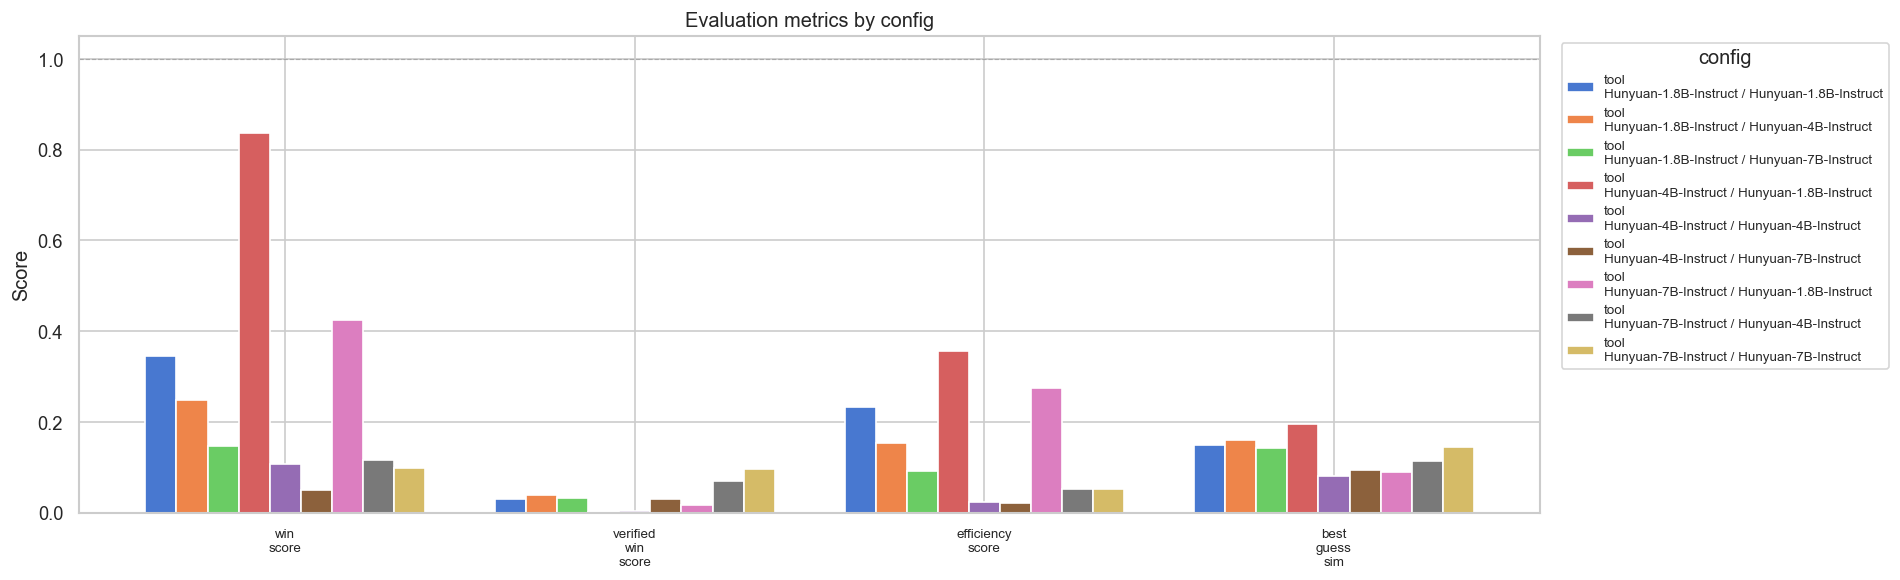

In [48]:
metrics = [
    "avg_win_score", "avg_verified_win_score", "avg_efficiency_score",
    "avg_best_guess_sim",#"avg_tool_calls_used",
]
# Only keep metrics that exist in this CSV (graceful for old data)
metrics = [m for m in metrics if m in df.columns]
labels = [m.replace("avg_", "").replace("_", "\n") for m in metrics]

mean_df = df.groupby("config")[metrics].mean()

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(metrics))
width = 0.8 / max(len(mean_df), 1)
colors = sns.color_palette("muted", len(mean_df))

for i, (config, row) in enumerate(mean_df.iterrows()):
    offset = (i - len(mean_df)/2 + 0.5) * width
    ax.bar(x + offset, row[metrics], width=width, label=config, color=colors[i], edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Score")
ax.set_title("Evaluation metrics by config")
ax.legend(title="config", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.7, alpha=0.5)
plt.tight_layout()
plt.show()


## 3 — Seed variance (stability across runs)
When you have multiple seeds per config, this shows how stable the results are. High variance = the model is sensitive to random seed.

/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_82828/3424938826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_82828/3424938826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_82828/3424938826.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=configs_with_

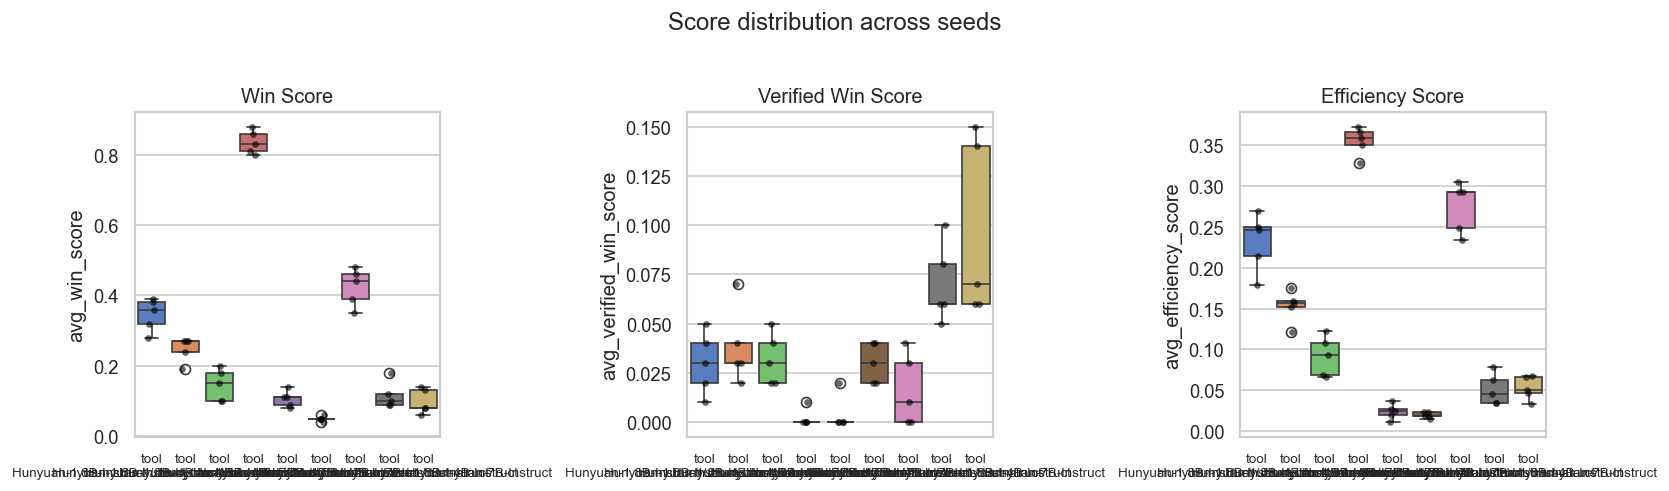

In [8]:
seed_metrics = ["avg_win_score", "avg_verified_win_score", "avg_efficiency_score", "avg_diversity"]
seed_metrics = [m for m in seed_metrics if m in df.columns]

configs_with_seeds = df.groupby("config").filter(lambda x: len(x) > 1)

if configs_with_seeds.empty:
    print("Need multiple seeds per config to show variance. Run submit_bulk_seeds.sh first.")
else:
    fig, axes = plt.subplots(1, len(seed_metrics), figsize=(max(14, len(seed_metrics) * 3.5), 4), sharey=False)
    if len(seed_metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, seed_metrics):
        sns.boxplot(data=configs_with_seeds, x="config", y=metric, ax=ax, palette="muted")
        sns.stripplot(data=configs_with_seeds, x="config", y=metric, ax=ax,
                      color="black", size=4, alpha=0.6, jitter=True)
        ax.set_title(metric.replace("avg_", "").replace("_", " ").title())
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelsize=8)
    plt.suptitle("Score distribution across seeds", y=1.02)
    plt.tight_layout()
    plt.show()


## 4 — Carbon footprint
CO2 per game and total energy by config. Useful for comparing the environmental cost of larger vs smaller models.

In [9]:
# Ensure numeric carbon columns
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()
carbon


,config,co2_per_game_g,energy_per_game_wh
0,tool\nHunyuan-1.8B-Instruct / Hunyuan-1.8B-Ins...,0.296048,2.846618
1,tool\nHunyuan-1.8B-Instruct / Hunyuan-4B-Instruct,0.355210,3.415483
2,tool\nHunyuan-1.8B-Instruct / Hunyuan-7B-Instruct,0.405738,3.901326
3,tool\nHunyuan-4B-Instruct / Hunyuan-1.8B-Instruct,0.154756,1.488037
4,tool\nHunyuan-4B-Instruct / Hunyuan-4B-Instruct,0.256793,2.469163
5,tool\nHunyuan-4B-Instruct / Hunyuan-7B-Instruct,0.353554,3.399557
6,tool\nHunyuan-7B-Instruct / Hunyuan-1.8B-Instruct,0.275079,2.644991
7,tool\nHunyuan-7B-Instruct / Hunyuan-4B-Instruct,0.445005,4.278898
8,tool\nHunyuan-7B-Instruct / Hunyuan-7B-Instruct,0.499835,4.806104


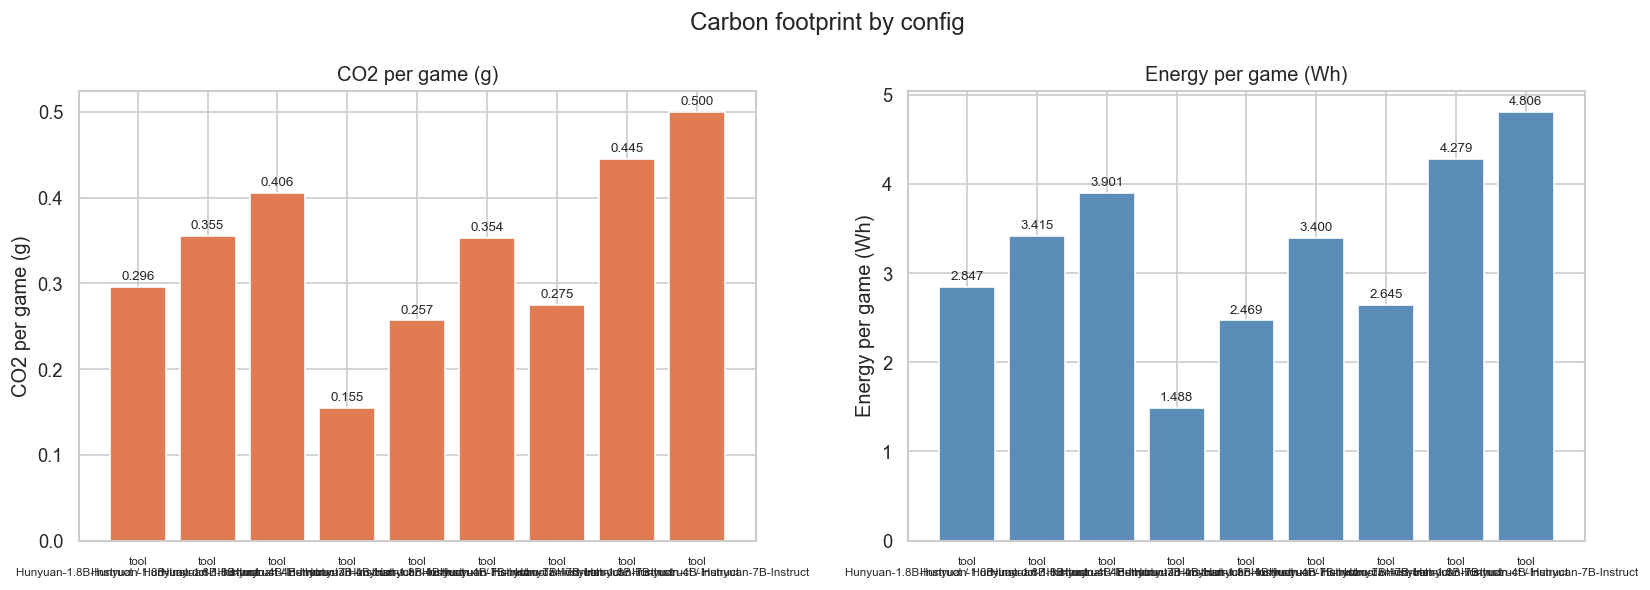

In [10]:
# Ensure numeric carbon columns
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

carbon = df.groupby("config")[["co2_per_game_g", "energy_per_game_wh"]].mean().reset_index()

if carbon[["co2_per_game_g", "energy_per_game_wh"]].isna().all().all():
    print("No valid carbon values (all NaN); skipping carbon bar plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, col, label, color in zip(
        axes,
        ["co2_per_game_g", "energy_per_game_wh"],
        ["CO2 per game (g)", "Energy per game (Wh)"],
        ["#e07b54", "#5b8db8"],
    ):
        tmp = carbon.dropna(subset=[col]).copy()
        if tmp.empty:
            ax.set_title(label)
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_xticks([])
            continue

        bars = ax.bar(tmp["config"], tmp[col], color=color, edgecolor="white")
        ax.set_ylabel(label)
        ax.set_title(label)
        ax.tick_params(axis="x", labelsize=7)
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(0)
            lbl.set_ha("center")

        ymax = float(tmp[col].max()) if len(tmp[col]) else 0.0
        offset = (ymax * 0.01) if ymax > 0 else 0.01
        for bar, val in zip(bars, tmp[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    plt.suptitle("Carbon footprint by config")
    plt.tight_layout()
    plt.show()


## 5 — Win rate vs CO₂ (efficiency frontier)

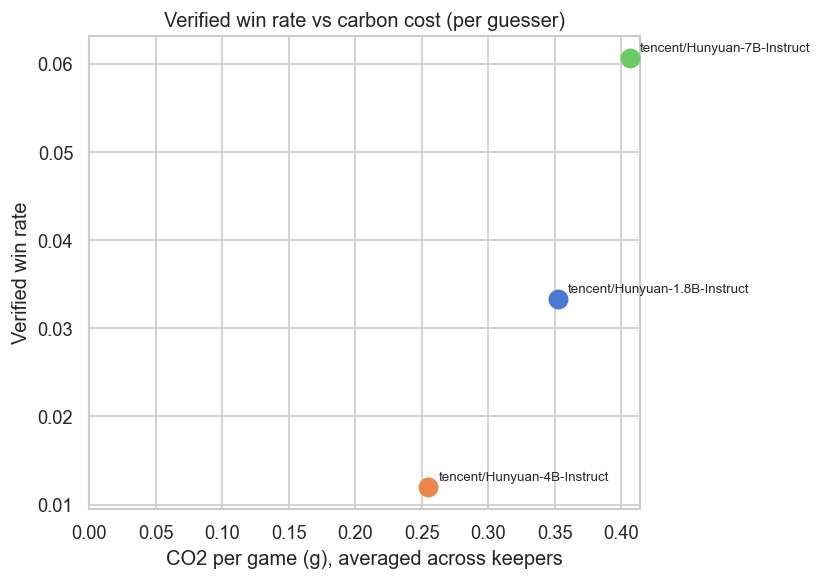

In [11]:
# Ensure numeric carbon columns
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

scatter = df.groupby("guesser_model").agg(
    verified_win=("avg_verified_win_score", "mean"),
    co2=("co2_per_game_g", "mean"),
).reset_index()

scatter = scatter.dropna(subset=["co2", "verified_win"])
if scatter.empty:
    print("No valid carbon values (co2 is NaN), skipping carbon scatter plot.")
else:
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = sns.color_palette("muted", len(scatter))

    for i, row in scatter.iterrows():
        ax.scatter(row["co2"], row["verified_win"], s=120, color=colors[i], zorder=3)
        ax.annotate(row["guesser_model"], (row["co2"], row["verified_win"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

    ax.set_xlabel("CO2 per game (g), averaged across keepers")
    ax.set_ylabel("Verified win rate")
    ax.set_title("Verified win rate vs carbon cost (per guesser)")
    ax.set_xlim(left=0)
    
    plt.tight_layout()
    plt.show()

## 5b — Per-guesser CO₂ vs win rate (main comparison)


/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_82828/4011978323.py:52: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jakobahlberg/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


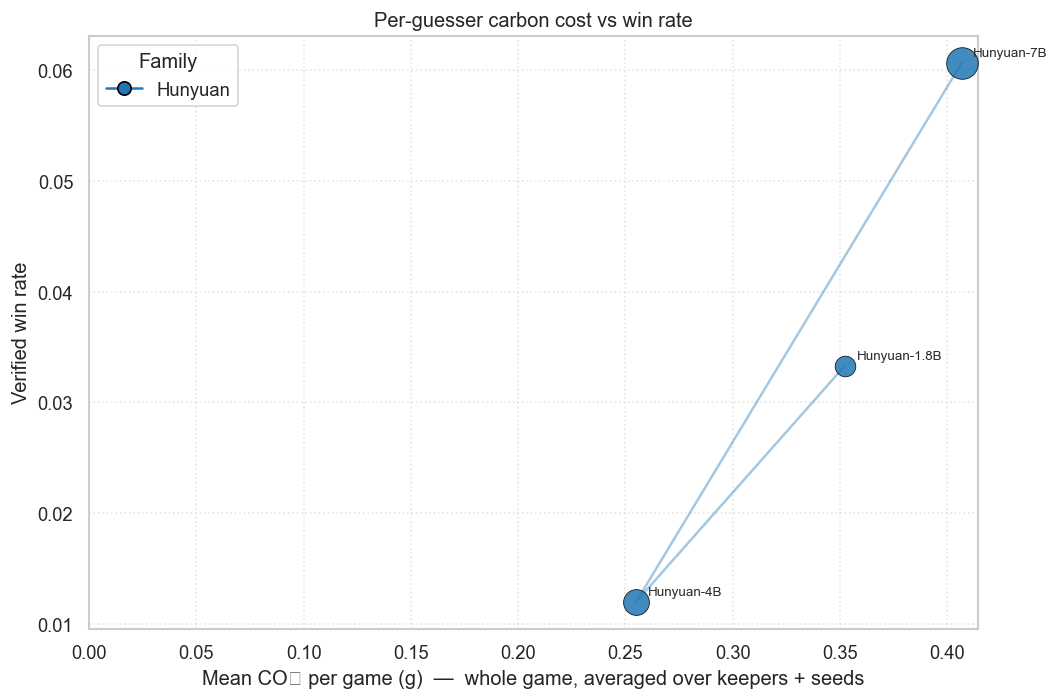

,guesser_short,family,co2,wh,win,win_std,size_b,n_runs
0,Hunyuan-1.8B,Hunyuan,0.352332,3.387809,0.033333,0.015430,1.8,15
1,Hunyuan-4B,Hunyuan,0.255034,2.452252,0.012000,0.015213,4.0,15
2,Hunyuan-7B,Hunyuan,0.406640,3.909997,0.060667,0.044476,7.0,15


In [12]:
for col in ["co2_per_game_g", "energy_per_game_wh"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

per_guesser = (
    df.groupby(["guesser_short", "family"])
      .agg(co2=("co2_per_game_g",         "mean"),
           wh =("energy_per_game_wh",     "mean"),
           win=("avg_verified_win_score", "mean"),
           win_std=("avg_verified_win_score", "std"),
           size_b=("size_b",              "first"),
           n_runs=("avg_verified_win_score", "size"))
      .reset_index()
      .dropna(subset=["co2", "win"])
)

if per_guesser.empty:
    print("No carbon data yet — re-run gather_results.py once new runs are in.")
else:
    family_colors = dict(zip(sorted(per_guesser["family"].unique()),
                             sns.color_palette("tab10", per_guesser["family"].nunique())))

    fig, ax = plt.subplots(figsize=(9, 6))

    # Connect points within a family in ascending size order — shows the family curve.
    for fam, sub in per_guesser.groupby("family"):
        sub_sorted = sub.sort_values("size_b")
        ax.plot(sub_sorted["co2"], sub_sorted["win"],
                "-", color=family_colors[fam], alpha=0.4, linewidth=1.5, zorder=1)

    for _, row in per_guesser.iterrows():
        size_b = row["size_b"] if pd.notna(row["size_b"]) else 1.0
        ax.scatter(row["co2"], row["win"],
                   s=80 + 40 * size_b,
                   color=family_colors[row["family"]],
                   edgecolor="black", linewidth=0.5, alpha=0.85, zorder=3)
        label = f"{row['guesser_short']}"
        ax.annotate(label, (row["co2"], row["win"]),
                    textcoords="offset points", xytext=(7, 4), fontsize=8)

    # Legend: one entry per family.
    handles = [plt.Line2D([0], [0], marker="o", linestyle="-",
                          color=family_colors[f], markeredgecolor="black",
                          markersize=8, label=f)
               for f in sorted(per_guesser["family"].unique())]
    ax.legend(handles=handles, title="Family", loc="best", frameon=True)

    ax.set_xlabel("Mean CO₂ per game (g)  —  whole game, averaged over keepers + seeds")
    ax.set_ylabel("Verified win rate")
    ax.set_xlim(left=0)
    ax.set_title("Per-guesser carbon cost vs win rate")
    ax.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

per_guesser


## 5c — CO₂ per game by guesser size (with win rate overlay)

Bars: mean CO₂/game per guesser, ordered by parameter count within each family.
Line: verified win rate on the right-hand axis. Reading: does going up the size axis cost more carbon than it buys in wins?


/var/folders/s_/ls3_g_dd5rvb7h7fy804r3_w0000gn/T/ipykernel_82828/336775057.py:41: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jakobahlberg/Library/Python/3.12/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


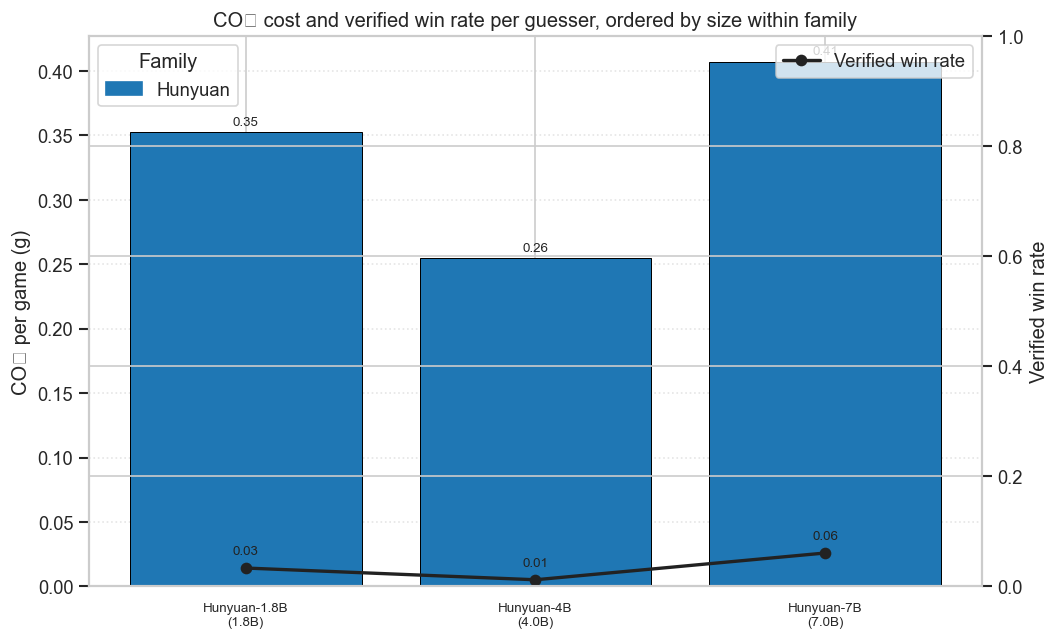

In [13]:
if per_guesser.empty:
    print("No carbon data yet — re-run gather_results.py once new runs are in.")
else:
    ordered = per_guesser.sort_values(["family", "size_b"]).reset_index(drop=True)
    family_colors = dict(zip(sorted(ordered["family"].unique()),
                             sns.color_palette("tab10", ordered["family"].nunique())))

    fig, ax = plt.subplots(figsize=(max(9, 0.7 * len(ordered)), 5.5))
    x = np.arange(len(ordered))
    bar_colors = [family_colors[f] for f in ordered["family"]]
    bars = ax.bar(x, ordered["co2"], color=bar_colors, edgecolor="black", linewidth=0.6)

    ax.set_xticks(x)
    labels = [f"{row.guesser_short}\n({row.size_b:.1f}B)" if pd.notna(row.size_b)
              else row.guesser_short for row in ordered.itertuples()]
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("CO₂ per game (g)")
    ax.set_title("CO₂ cost and verified win rate per guesser, ordered by size within family")
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    for bar, val in zip(bars, ordered["co2"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

    # Family-boundary dividers
    fam_runs = ordered["family"].tolist()
    for i in range(1, len(fam_runs)):
        if fam_runs[i] != fam_runs[i - 1]:
            ax.axvline(i - 0.5, color="grey", linestyle="--", linewidth=0.7, alpha=0.6)

    ax2 = ax.twinx()
    ax2.plot(x, ordered["win"], "o-", color="#222222", linewidth=2, markersize=6, label="Verified win rate")
    ax2.set_ylabel("Verified win rate")
    ax2.set_ylim(0, 1.0)
    for xi, w in zip(x, ordered["win"]):
        ax2.text(xi, w + 0.02, f"{w:.2f}", ha="center", va="bottom", fontsize=8, color="#222222")

    handles = [plt.Rectangle((0, 0), 1, 1, color=family_colors[f]) for f in sorted(family_colors)]
    ax.legend(handles, sorted(family_colors), title="Family", loc="upper left", frameon=True)
    ax2.legend(loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()


## 6 — Guesser × Secret keeper win rate heatmap
Which (guesser, secret keeper) model pairings lead to the highest win rates? Each cell shows the mean win rate for that combination.

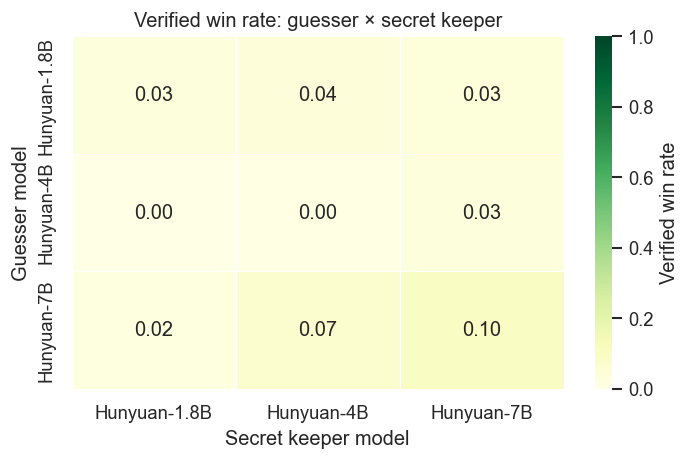

In [14]:
pivot = df.groupby(["guesser_short", "secret_short"])["avg_verified_win_score"].mean().unstack()

if pivot.shape[0] < 2 or pivot.shape[1] < 2:
    print("Need multiple guesser and secret keeper model variants to build this heatmap.")
else:
    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1] * 1.5), max(4, pivot.shape[0] * 1.2)))
    sns.heatmap(
        pivot, annot=True, fmt=".2f", cmap="YlGn",
        linewidths=0.5, ax=ax, vmin=0, vmax=1,
        cbar_kws={"label": "Verified win rate"},
    )
    ax.set_xlabel("Secret keeper model")
    ax.set_ylabel("Guesser model")
    ax.set_title("Verified win rate: guesser × secret keeper")
    plt.tight_layout()
    plt.show()


## 6b — Secret keeper accuracy heatmap
Same guesser × secret keeper grid, but showing `avg_secret_keeper_accuracy` instead of win rate. Helps separate "the guesser was bad" from "the secret keeper was unreliable".

In [15]:
if "avg_secret_keeper_accuracy" not in df.columns:
    print("avg_secret_keeper_accuracy not found — re-run gather_results.py with new data.")
else:
    sk_pivot = df.groupby(["guesser_label", "secret_label"])["avg_secret_keeper_accuracy"].mean().unstack()

    if sk_pivot.shape[0] < 2 or sk_pivot.shape[1] < 2:
        print("Need multiple guesser and secret keeper model variants to build this heatmap.")
    else:
        fig, ax = plt.subplots(figsize=(max(6, sk_pivot.shape[1] * 1.5), max(4, sk_pivot.shape[0] * 1.2)))
        sns.heatmap(
            sk_pivot, annot=True, fmt=".2f", cmap="YlGn",
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            cbar_kws={"label": "Avg secret keeper accuracy"},
        )
        ax.set_xlabel("Secret keeper model")
        ax.set_ylabel("Guesser model")
        ax.set_title("Secret keeper accuracy: guesser × secret keeper")
        plt.tight_layout()
        plt.show()


avg_secret_keeper_accuracy not found — re-run gather_results.py with new data.


## 7 — Metric correlation heatmap
Which metrics tend to move together? Helps understand whether the evaluation layers are measuring different things or overlapping.

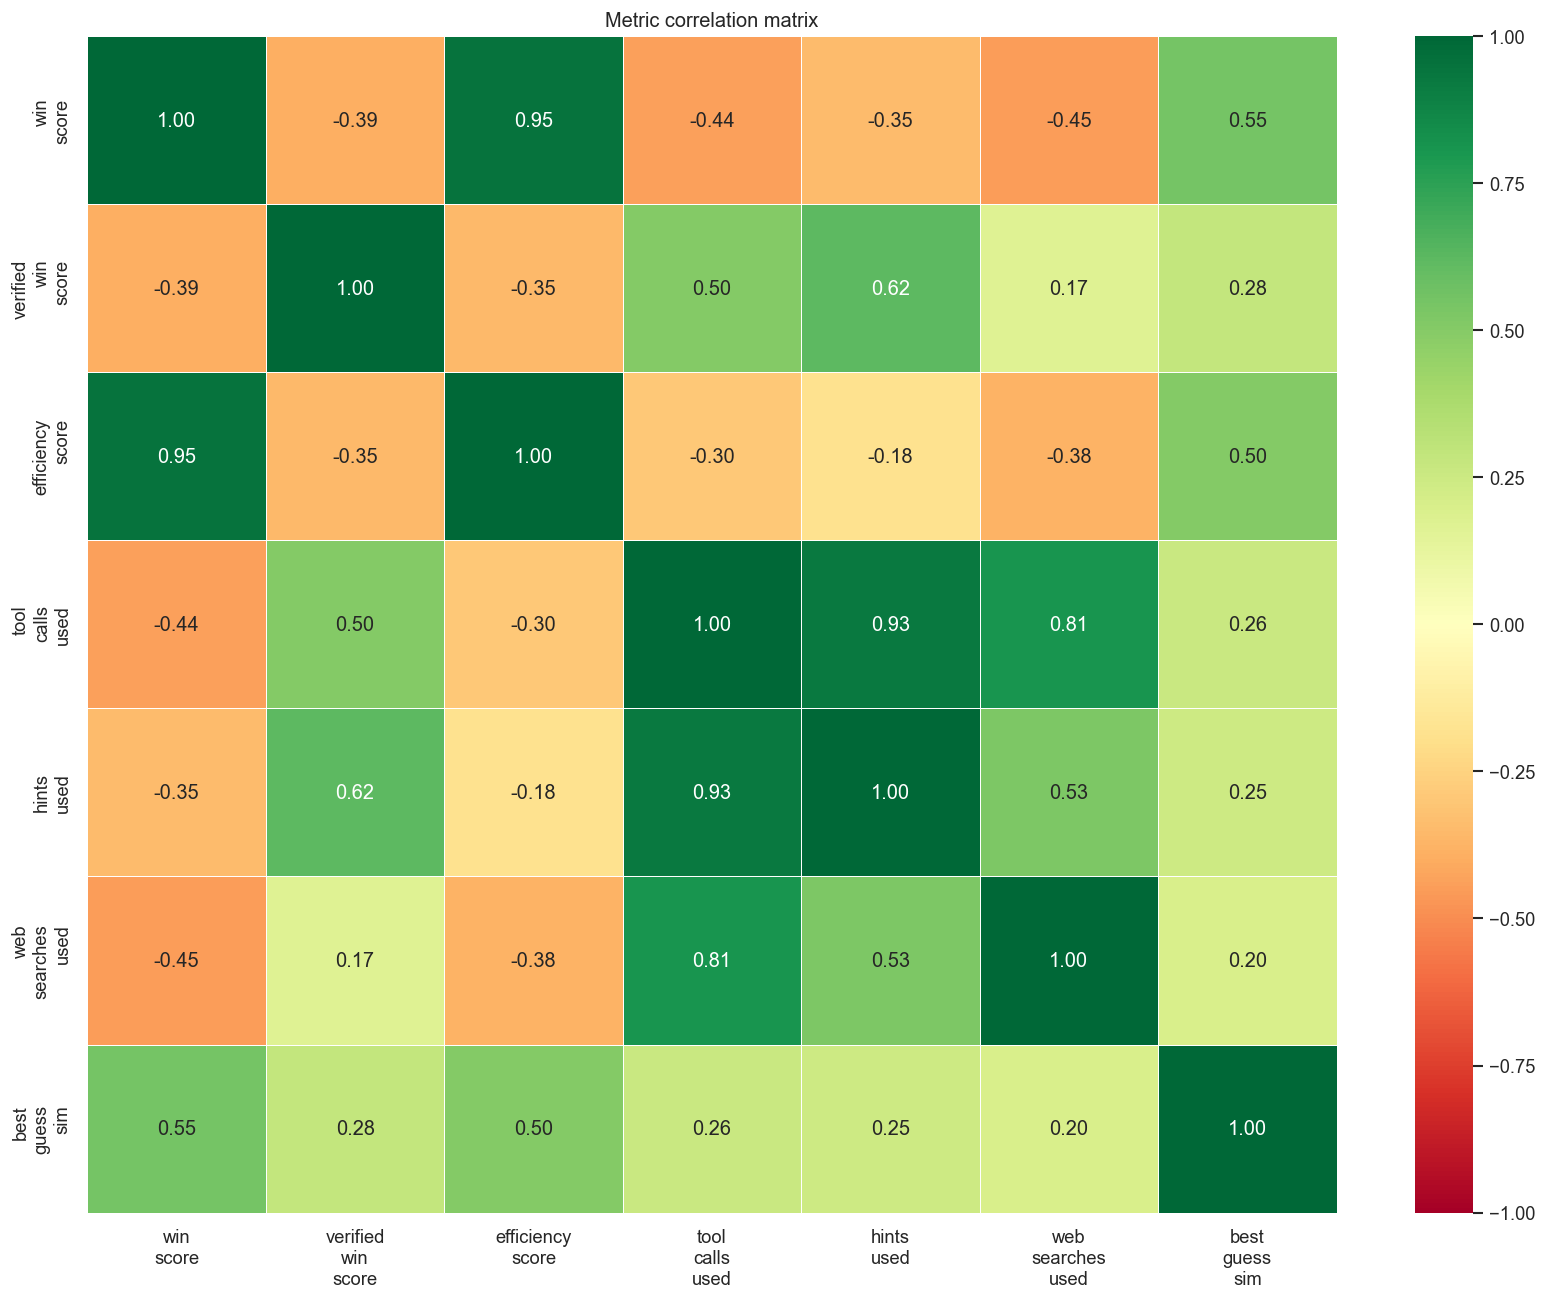

In [16]:
if len(df) < 3:
    print("Need at least 3 runs to compute meaningful correlations.")
else:
    corr_cols = [
        "avg_win_score", "avg_verified_win_score", "avg_efficiency_score",
        "avg_tool_calls_used", "avg_hints_used", "avg_web_searches_used",
        "avg_best_guess_sim",
    ]
    corr_cols = [c for c in corr_cols if c in df.columns]
    corr = df[corr_cols].corr()
    short = [c.replace("avg_", "").replace("_", "\n") for c in corr_cols]

    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                xticklabels=short, yticklabels=short,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title("Metric correlation matrix")
    plt.tight_layout()
    plt.show()


## 8 — Publication-ready summary plots

Two figures saved to `results/plots/`: keeper honesty (raw vs verified win %, false-correct rate, win survival) and guesser summary (win rates, tool usage, efficiency). Adapted from `make_plots.py` to use the in-notebook `df`. Orders are derived from the data (keepers large→small, guessers best→worst raw win%).

In [17]:
from collections import defaultdict

# Models that should be hidden from the GUESSER plot (broken plumbing — never
# emits a valid final guess). Add short names here, e.g. {"Qwen3.5-2B"}.
BROKEN_GUESSERS: set[str] = set()


def _aggregate_by(frame, key_col):
    """Mirror make_plots.aggregate_by but on an in-memory DataFrame."""
    out = {}
    for k, sub in frame.groupby(key_col):
        ng  = int(sub["num_games"].sum())
        nw  = int(sub["num_wins"].sum())
        nv  = int(sub["num_verified_wins"].sum())
        nfc = int(sub["num_false_correct"].sum()) if "num_false_correct" in sub else 0
        out[k] = {
            "n_games":  ng,
            "raw":      nw / ng * 100 if ng else 0.0,
            "verified": nv / ng * 100 if ng else 0.0,
            "fc":       nfc,
            "fc_pct":   nfc / ng * 100 if ng else 0.0,
            "survival": min(100.0, nv / nw * 100) if nw else 100.0,
            "tools":    sub["avg_tool_calls_used"].mean()    if "avg_tool_calls_used"    in sub else float("nan"),
            "eff":      sub["avg_efficiency_score"].mean()   if "avg_efficiency_score"   in sub else float("nan"),
        }
    return out


by_keeper  = _aggregate_by(df, "secret_short")
by_guesser = _aggregate_by(df[~df["guesser_short"].isin(BROKEN_GUESSERS)], "guesser_short")

# Keeper order: largest → smallest parameter count (fall back to name sort)
def _size_key(name):
    m = re.search(r"([\d.]+)\s*[Bb]\b", str(name))
    return float(m.group(1)) if m else 0.0

KEEPER_ORDER  = sorted(by_keeper.keys(),  key=_size_key, reverse=True)
# Guesser order: best raw win% first
GUESSER_ORDER = sorted(by_guesser.keys(), key=lambda g: by_guesser[g]["raw"], reverse=True)

print("Keeper order :", KEEPER_ORDER)
print("Guesser order:", GUESSER_ORDER)

Keeper order : ['Hunyuan-7B', 'Hunyuan-4B', 'Hunyuan-1.8B']
Guesser order: ['Hunyuan-4B', 'Hunyuan-1.8B', 'Hunyuan-7B']


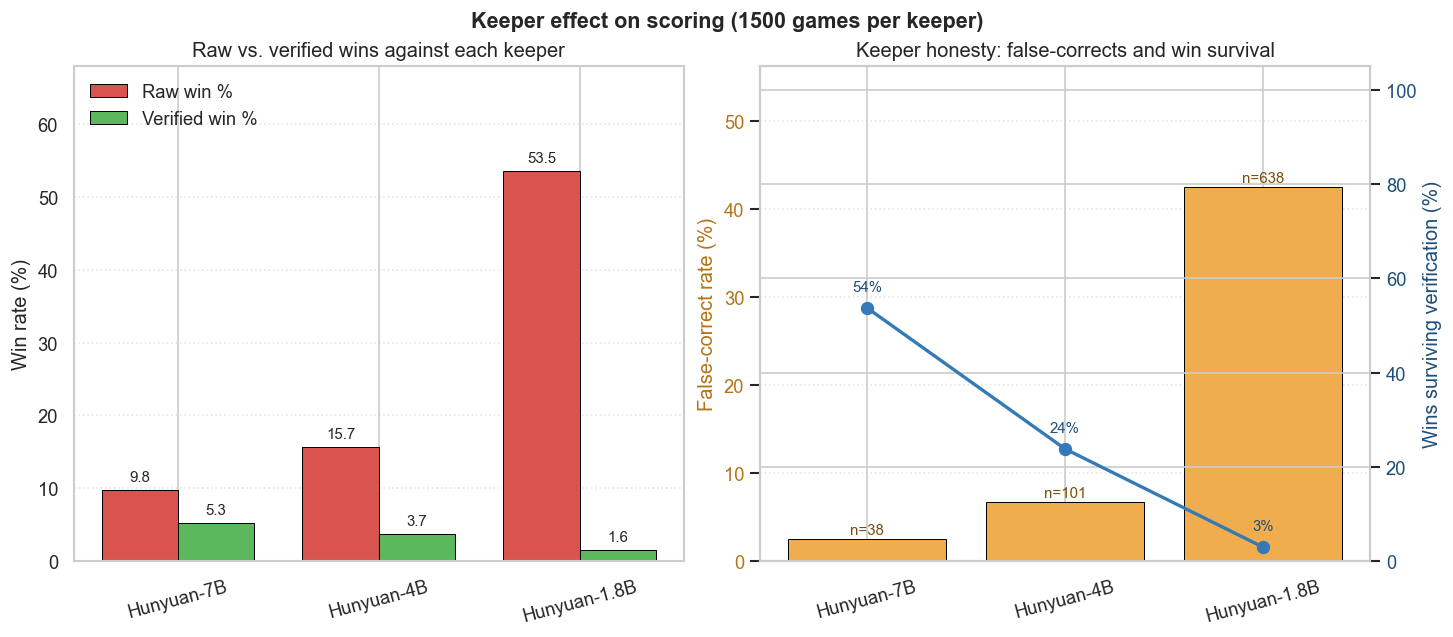

In [18]:
# --- PLOT 1: Keeper honesty — raw win% vs verified%, false-corrects, survival ---
keepers  = KEEPER_ORDER
raw      = [by_keeper[k]["raw"]      for k in keepers]
verified = [by_keeper[k]["verified"] for k in keepers]
fc       = [by_keeper[k]["fc"]       for k in keepers]
survival = [by_keeper[k]["survival"] for k in keepers]
n_total_per_keeper = by_keeper[keepers[0]]["n_games"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)

x = np.arange(len(keepers))
w = 0.38
b1 = ax1.bar(x - w/2, raw,      w, label="Raw win %",     color="#d9534f", edgecolor="black", linewidth=0.6)
b2 = ax1.bar(x + w/2, verified, w, label="Verified win %", color="#5cb85c", edgecolor="black", linewidth=0.6)
ax1.set_xticks(x); ax1.set_xticklabels(keepers, rotation=15)
ax1.set_ylabel("Win rate (%)")
ax1.set_title("Raw vs. verified wins against each keeper")
ax1.set_ylim(0, max(max(raw, default=0), max(verified, default=0)) * 1.25 + 1)
ax1.legend(loc="upper left", frameon=False)
ax1.grid(axis="y", linestyle=":", alpha=0.5)
for bars in (b1, b2):
    for b in bars:
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                 f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=9)

fc_pct = [by_keeper[k]["fc_pct"] for k in keepers]
b3 = ax2.bar(keepers, fc_pct, color="#f0ad4e", edgecolor="black", linewidth=0.6, label="False-correct rate")
ax2.set_ylabel("False-correct rate (%)", color="#b37419")
ax2.tick_params(axis="y", labelcolor="#b37419")
ax2.set_ylim(0, max(fc_pct, default=1) * 1.3 + 1)
for b, n in zip(b3, fc):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.25,
             f"n={n}", ha="center", va="bottom", fontsize=9, color="#7a4e0f")

ax2b = ax2.twinx()
ax2b.plot(keepers, survival, "o-", color="#337ab7", linewidth=2, markersize=7, label="Verified-win survival %")
ax2b.set_ylabel("Wins surviving verification (%)", color="#1f4f7a")
ax2b.tick_params(axis="y", labelcolor="#1f4f7a")
ax2b.set_ylim(0, 105)
for k, s in zip(keepers, survival):
    ax2b.text(k, s + 3, f"{s:.0f}%", ha="center", va="bottom", fontsize=9, color="#1f4f7a")

ax2.set_title("Keeper honesty: false-corrects and win survival")
ax2.set_xticks(x); ax2.set_xticklabels(keepers, rotation=15)
ax2.grid(axis="y", linestyle=":", alpha=0.5)

fig.suptitle(f"Keeper effect on scoring ({n_total_per_keeper} games per keeper)",
             fontsize=13, fontweight="bold")
plt.show()

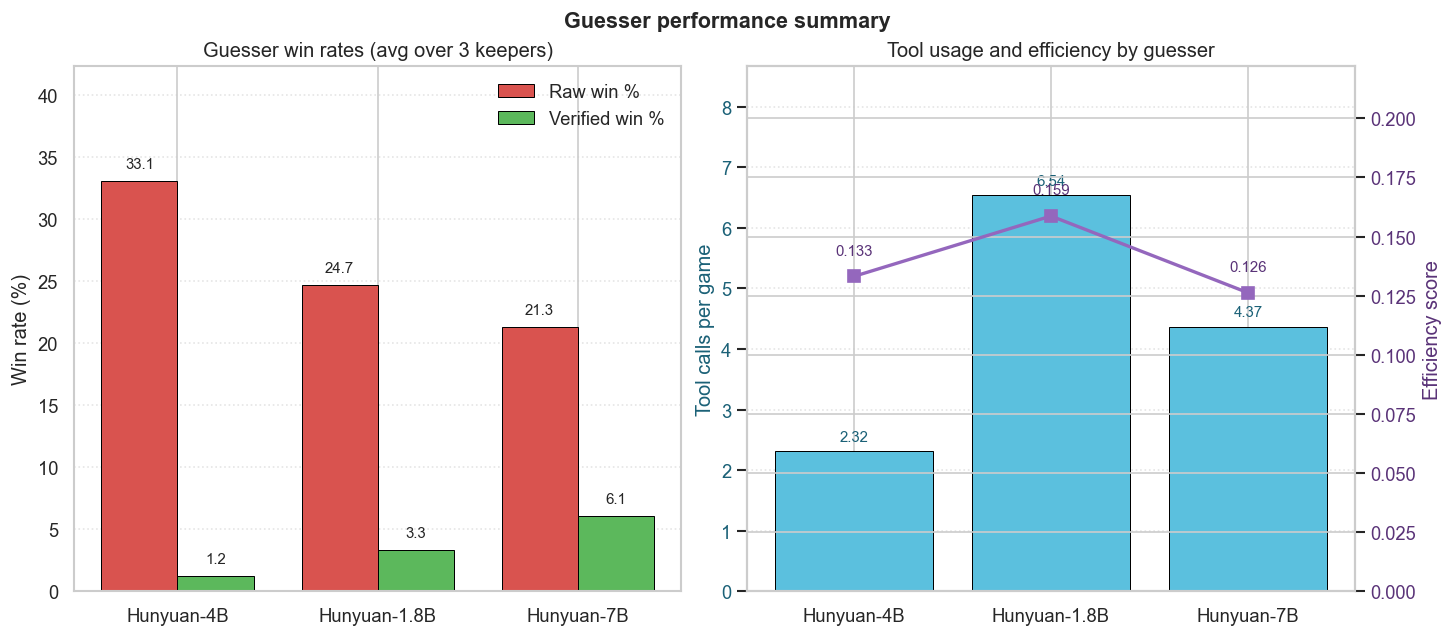

In [19]:
# --- PLOT 2: Guesser performance — win%, verified%, tools, efficiency ---
guessers   = GUESSER_ORDER
g_win      = [by_guesser[g]["raw"]      for g in guessers]
g_verified = [by_guesser[g]["verified"] for g in guessers]
g_tools    = [by_guesser[g]["tools"]    for g in guessers]
g_eff      = [by_guesser[g]["eff"]      for g in guessers]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True)

x = np.arange(len(guessers))
w = 0.38
bL1 = axL.bar(x - w/2, g_win,      w, label="Raw win %",      color="#d9534f", edgecolor="black", linewidth=0.6)
bL2 = axL.bar(x + w/2, g_verified, w, label="Verified win %", color="#5cb85c", edgecolor="black", linewidth=0.6)
axL.set_xticks(x); axL.set_xticklabels(guessers)
axL.set_ylabel("Win rate (%)")
n_keepers = df["secret_short"].nunique()
axL.set_title(f"Guesser win rates (avg over {n_keepers} keepers)")
axL.set_ylim(0, max(max(g_win, default=0), max(g_verified, default=0)) * 1.25 + 1)
axL.legend(loc="upper right", frameon=False)
axL.grid(axis="y", linestyle=":", alpha=0.5)
for bars in (bL1, bL2):
    for b in bars:
        axL.text(b.get_x() + b.get_width()/2, b.get_height() + 0.8,
                 f"{b.get_height():.1f}", ha="center", va="bottom", fontsize=9)

bR = axR.bar(guessers, g_tools, color="#5bc0de", edgecolor="black", linewidth=0.6, label="Tool calls / game")
axR.set_ylabel("Tool calls per game", color="#1b6177")
axR.tick_params(axis="y", labelcolor="#1b6177")
axR.set_ylim(0, max(g_tools, default=1) * 1.25 + 0.5)
for b, t in zip(bR, g_tools):
    axR.text(b.get_x() + b.get_width()/2, b.get_height() + 0.12,
             f"{t:.2f}", ha="center", va="bottom", fontsize=9, color="#1b6177")

axR2 = axR.twinx()
axR2.plot(guessers, g_eff, "s-", color="#9467bd", linewidth=2, markersize=7, label="Efficiency")
axR2.set_ylabel("Efficiency score", color="#5a3378")
axR2.tick_params(axis="y", labelcolor="#5a3378")
axR2.set_ylim(0, max(max(g_eff, default=0.1) * 1.4, 0.1))
for g, e in zip(guessers, g_eff):
    axR2.text(g, e + max(g_eff, default=0.1) * 0.05, f"{e:.3f}",
              ha="center", va="bottom", fontsize=9, color="#5a3378")

axR.set_title("Tool usage and efficiency by guesser")
axR.grid(axis="y", linestyle=":", alpha=0.5)

fig.suptitle("Guesser performance summary", fontsize=13, fontweight="bold")
plt.show()

## 9 — Carbon footprint across all model families

Loads every `results/*_fixed*.csv`, reapplies the fixed DK-DK2 intensity (104 gCO₂eq/kWh), and plots mean energy per game (Wh) by guesser model — one panel per family, ordered by parameter count. No win information: this is a pure energy characterisation for the results / limitations discussion.

**Expected:** larger models consume more energy (more parameters → more FLOPs per token).  
**Observed:** non-monotonic or even inverted patterns in several families (e.g. Granite 2B > 8B, Qwen 4B > 9B).  
**Likely cause:** GPU power is measured wall-clock via NVML/RAPL and includes idle time while tool calls (web search, etc.) complete. Small, fast models finish their generation quickly but leave the GPU idling at high power draw for the same tool latency — so raw energy-per-game can be higher for the smaller model.

Loaded 235 runs from 5 CSV files


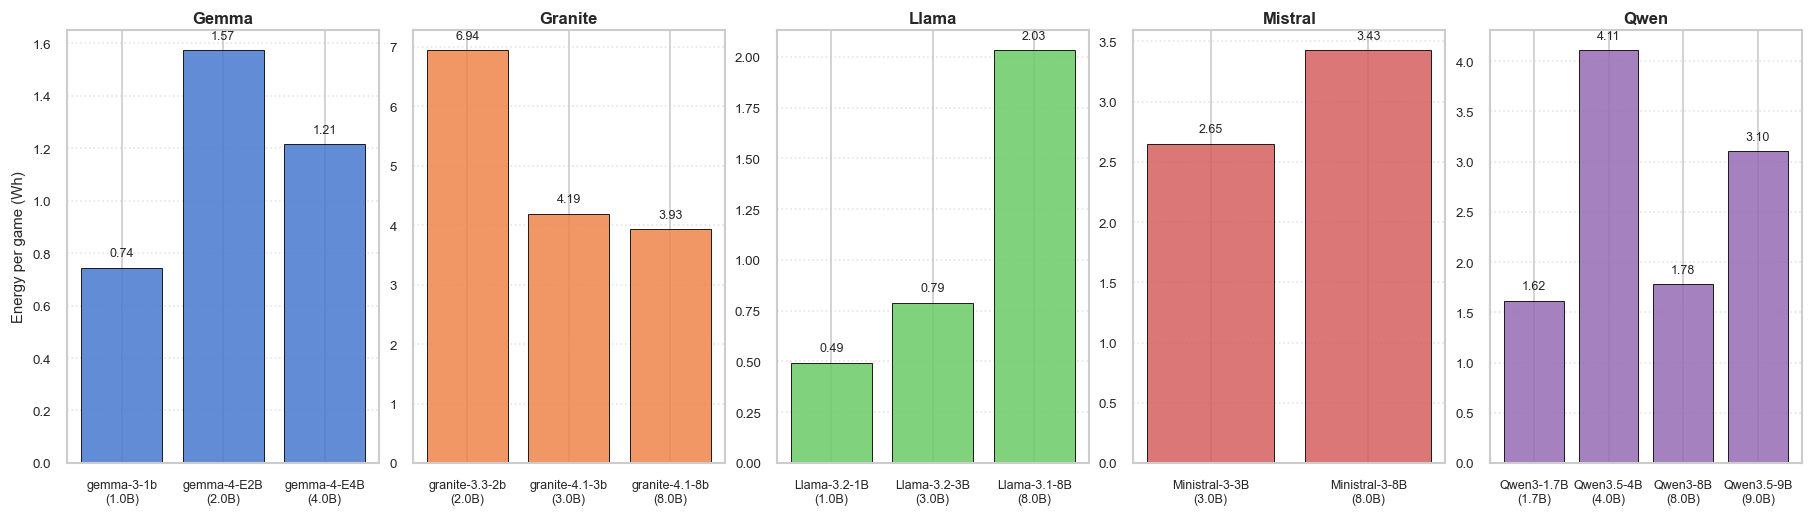

Saved → docs/figures/carbon_by_family.{pdf,png}


In [23]:
import glob, os, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

CO2_INTENSITY_G_PER_KWH = 104.0  # DK-DK2, Apr 2026

# ── helpers (self-contained so this cell runs independently) ─────────────────

def _plot_label(name: str) -> str:
    n = str(name).split("/")[-1]
    for suf in ["-Instruct-2512-BF16", "-Instruct", "-instruct", "-it"]:
        n = n.replace(suf, "")
    return n


def _family(name: str) -> str:
    n = str(name).lower()
    if "qwen" in n:                          return "Qwen"
    if "llama" in n:                         return "Llama"
    if "gemma" in n:                         return "Gemma"
    if "mistral" in n or "ministral" in n:   return "Mistral"
    if "granite" in n:                       return "Granite"
    return "Other"


def _size_b(name: str) -> float:
    s = str(name)
    hits = re.findall(r"([\d.]+)\s*[Bb]\b", s)
    if hits:
        try:
            return float(hits[-1])
        except ValueError:
            pass
    m = re.search(r"[-_]([\d.]+)b[-_]", s.lower())
    return float(m.group(1)) if m else float("nan")


# ── load & merge all fixed CSVs ───────────────────────────────────────────────

frames = [pd.read_csv(p) for p in sorted(glob.glob("results/results_*_fixed*.csv"))]
all_df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(all_df)} runs from {len(frames)} CSV files")

all_df["energy_per_game_wh"] = pd.to_numeric(all_df["energy_per_game_wh"], errors="coerce")
all_df["co2_per_game_g"]     = all_df["energy_per_game_wh"] / 1000.0 * CO2_INTENSITY_G_PER_KWH
all_df["guesser_label"]      = all_df["guesser_model"].apply(_plot_label)
all_df["family"]             = all_df["guesser_model"].apply(_family)
all_df["size_b"]             = all_df["guesser_model"].apply(_size_b)

# Mean across all runs (seeds × keeper configurations)
per_guesser = (
    all_df.groupby(["guesser_label", "family", "guesser_model"])
    .agg(
        wh_mean  = ("energy_per_game_wh", "mean"),
        co2_mean = ("co2_per_game_g",     "mean"),
        size_b   = ("size_b",             "first"),
    )
    .reset_index()
    .sort_values(["family", "size_b"])
    .reset_index(drop=True)
)

# ── plot ──────────────────────────────────────────────────────────────────────

FAMILY_ORDER = ["Gemma", "Granite", "Llama", "Mistral", "Qwen"]
families = [f for f in FAMILY_ORDER if f in per_guesser["family"].values]

FAMILY_COLORS = {
    "Gemma":   "#4878d0",
    "Granite": "#ee854a",
    "Llama":   "#6acc65",
    "Mistral": "#d65f5f",
    "Qwen":    "#956cb4",
}

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(
    1, len(families),
    figsize=(3.0 * len(families), 4.2),
    sharey=False,
    constrained_layout=True,
)
if len(families) == 1:
    axes = [axes]

for ax, fam in zip(axes, families):
    sub = per_guesser[per_guesser["family"] == fam].sort_values("size_b")
    x   = np.arange(len(sub))
    col = FAMILY_COLORS.get(fam, "#aaaaaa")

    ax.bar(x, sub["wh_mean"], color=col, edgecolor="black", linewidth=0.6, alpha=0.85)

    xlabels = []
    for row in sub.itertuples():
        size_str = f"\n({row.size_b:.1f}B)" if pd.notna(row.size_b) else ""
        xlabels.append(row.guesser_label + size_str)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=7.5)
    ax.set_title(fam, fontsize=10, fontweight="bold", pad=4)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="y", labelsize=8)

    for xi, (_, row) in zip(x, sub.iterrows()):
        ax.text(xi, row["wh_mean"] + ax.get_ylim()[1] * 0.02,
                f"{row['wh_mean']:.2f}", ha="center", va="bottom", fontsize=7.5)

axes[0].set_ylabel("Energy per game (Wh)", fontsize=9)

os.makedirs("docs/figures", exist_ok=True)
fig.savefig("docs/figures/carbon_by_family.pdf", bbox_inches="tight")
fig.savefig("docs/figures/carbon_by_family.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/figures/carbon_by_family.{pdf,png}")